In [36]:
import os  
os.getcwd()

'C:\\Users\\Admin\\ml  models - p'

In [37]:
#  logestic regressuion  model 
#  this is  classification  model  when  our  target  data  is  categorical  , then  we  can use  this  model   
#  in backend  ,  activation function (sigmoid) ------->>>>>  convert into probability(0-1) ------>>>> 
#  threshould_value = 1/2 or  0.5

   # if  x > 0.5:
   #     return  1
   # else:
   #     return 0 

In [38]:
import  numpy as  np 
import  pandas as pd  
df = pd.read_csv("C:\\Users\\Admin\\ml  models - p\\covid_toy.csv")
df.head(2)

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes


In [39]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [40]:
df['fever'] =  df['fever'].fillna(df['fever'].mean())

In [41]:
df.isnull().sum()

age          0
gender       0
fever        0
cough        0
city         0
has_covid    0
dtype: int64

In [42]:
from sklearn.preprocessing import  LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['cough'] = le.fit_transform(df['cough'])
df['city'] = le.fit_transform(df['city'])
df['has_covid'] = le.fit_transform(df['has_covid'])

In [43]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,1,103.0,0,2,0
1,27,1,100.0,0,1,1
2,42,1,101.0,0,1,0
3,31,0,98.0,0,2,0
4,65,0,101.0,0,3,0


In [44]:

x = df.drop(columns=['has_covid'])
y= df['has_covid']

In [45]:

from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state = 42)

In [46]:
from  sklearn.linear_model import LogisticRegression 
lr =  LogisticRegression()

In [47]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred =  lr.predict(x_test)

In [49]:



from  sklearn.metrics import accuracy_score

In [50]:

accuracy_score(y_test,y_pred)

0.75

In [51]:
# Sigmoid converts the linear score z (which is calculated from X values) into a probability.

In [52]:
# 1.️ X values (features)
# 2.️ Model computes

#                  𝑧 = 𝑤 𝑋+𝑏

# 3.️ Sigmoid converts z → probability (0–1)

# X = raw inputs

# z = combined score from X

# Only z goes into sigmoid

In [53]:
# 1.Take all X feature values of that row
# 2️. Compute
#          z=wX+b
# 3. This gives one single value z
# 4. Apply sigmoid → one probability

In [54]:
# Memory shortcut :- 

# X → z → sigmoid → probability → threshold → class

In [55]:
# For multiple rows

# 1 row → 1 z → 1 probability

# 10 rows → 10 z values → 10 probabilities

In [56]:
#  apply  on  titanic  data  

In [57]:
import  numpy as  np 
import  pandas as pd  

import  seaborn as sns 
import  matplotlib.pyplot as plt 
df = pd.read_csv("C:\\Users\\Admin\\ml  models - p\\titanic.csv")   #  not work  on y  becuse  y  dont  have  nan
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [58]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


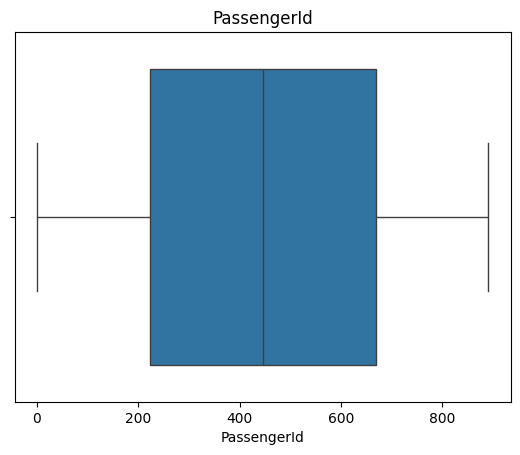

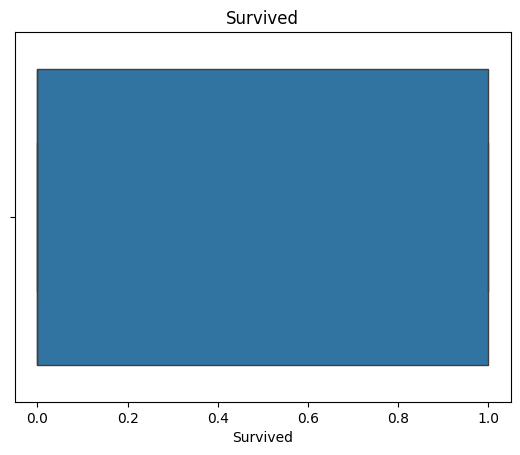

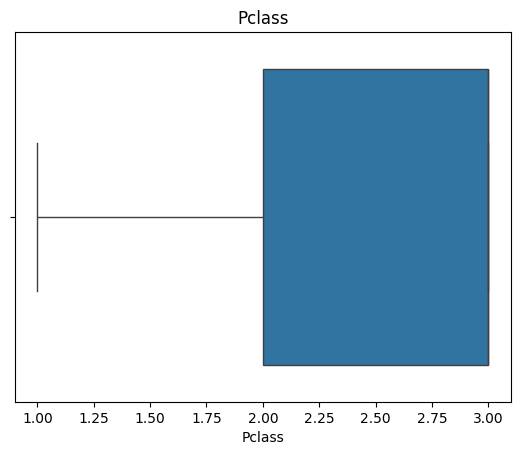

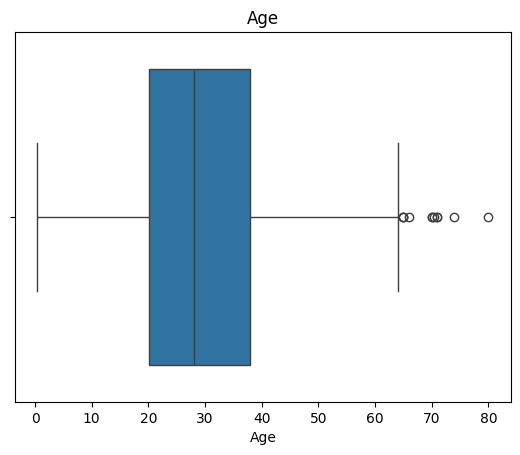

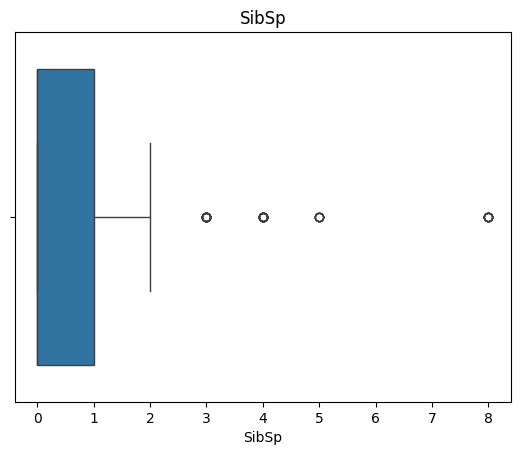

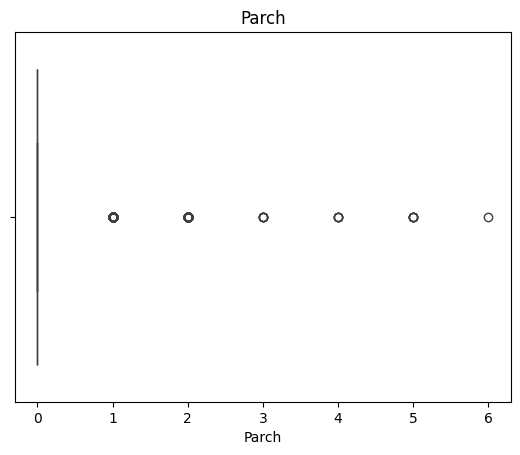

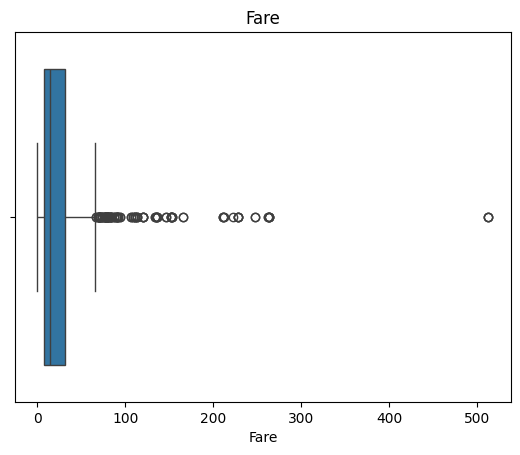

In [59]:
# outlier  check  :-
num= df.select_dtypes(include=['number']).columns.to_list()
for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()
    


In [60]:
percentaile_75 = df[num].quantile(0.75)
percentaile_25 = df[num].quantile(0.25)

IQR =  percentaile_75 - percentaile_25 

upper_limit = percentaile_75 + 1.5*IQR
lower_limit = percentaile_25 - 1.5*IQR

df[num] = df[num].clip(lower = lower_limit,upper = upper_limit,axis=1)

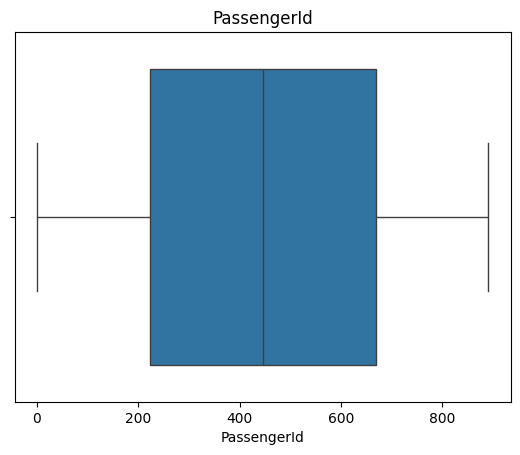

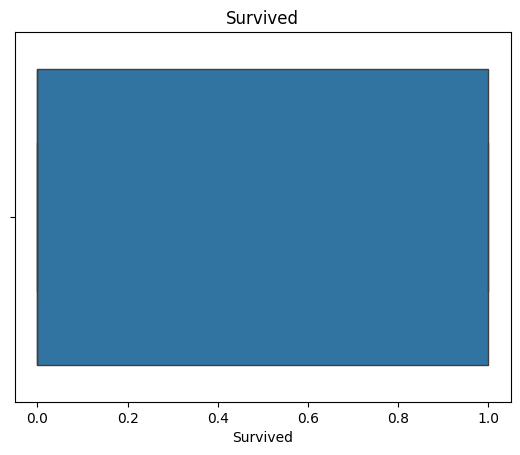

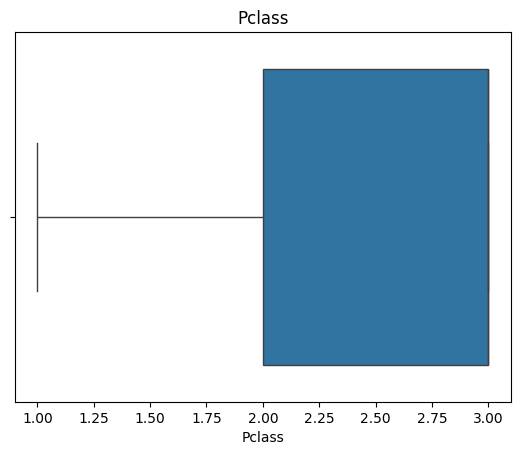

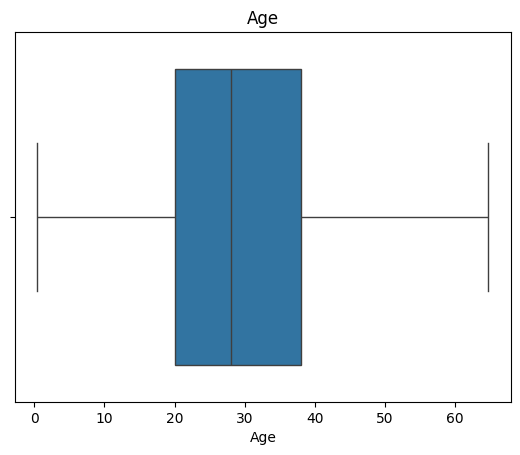

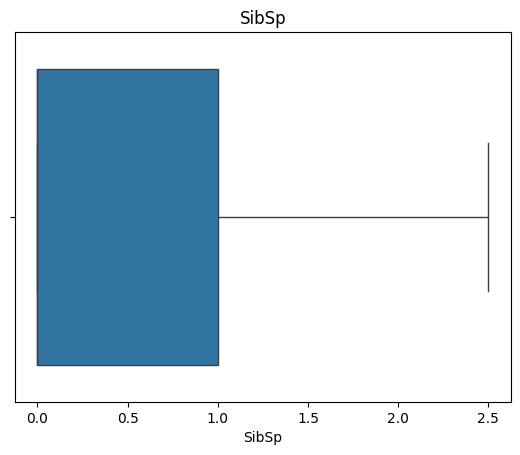

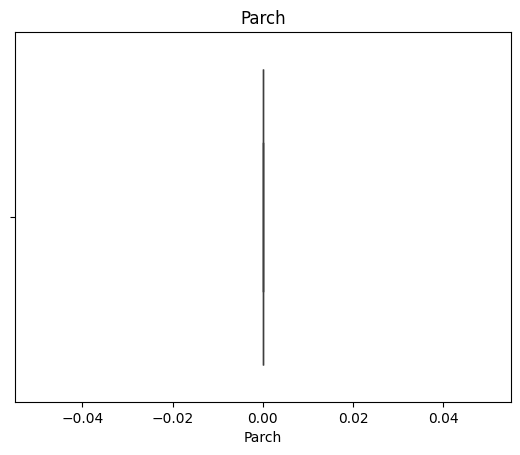

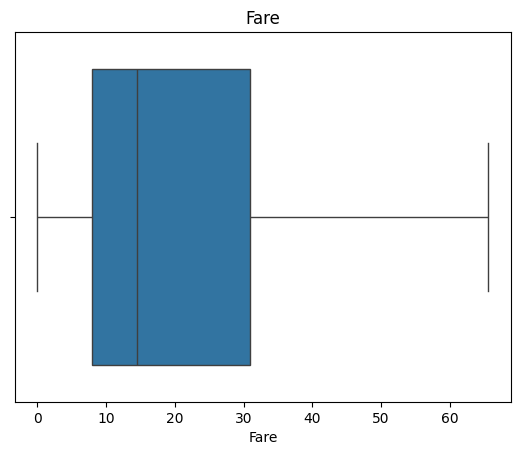

In [61]:
for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [62]:
#  now cca:- 
cols  = [var  for var in df.columns  if  df [var].isnull().mean() < 0.05 and  df[var].isnull().mean()>0]
cols

['Embarked']

In [63]:
# len(df) numer of rows show :-
# This shows NON-MISSING data proportion
len(df[cols].dropna()) / len(df)
new_df = df[cols].dropna()

<Axes: >

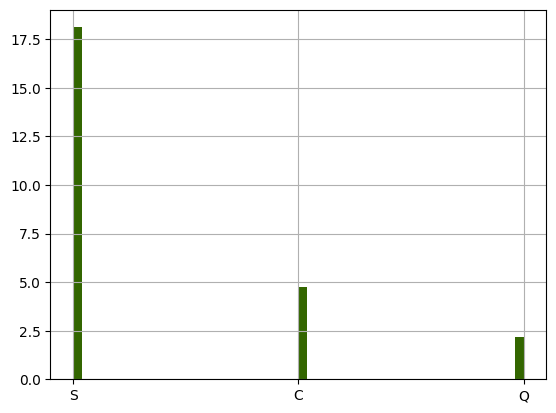

In [64]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original data 
df['Embarked'].hist(bins=50,ax=ax,density = True ,color='red')
# data after cca ,the argument alpha make the color transparaent ,so we can 
# see the overlay of the 2 distrribution 
new_df['Embarked'].hist(bins=50,ax=ax,density = True ,color='green',alpha=0.8)

In [65]:
# final  conclusion  we drop  [Fare columns] and  fill  other columns  

In [66]:
df = df.dropna(subset=['Embarked'])
#  now we  use  simple  imputer  for that  misisng  value  which  are  under 5% but  affect  histogram  and also  that  columns  which  have  
# missing  value  but  morethan  5%  mising  value  so  the  are also  imput  in  whith  those  columns  in columns tranformer 

In [67]:
from  sklearn.impute import  SimpleImputer
from  sklearn.compose import  ColumnTransformer 
from  sklearn.pipeline  import  Pipeline


from  sklearn.preprocessing  import  StandardScaler
from  sklearn.preprocessing  import  OneHotEncoder

In [68]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [69]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0,373450,8.0500,NaN,S


In [70]:
from sklearn.model_selection import train_test_split 


In [71]:
x=df.drop(columns=['Survived'])
y=df['Survived']


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [72]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin'] # removeing  unwanted columns

x_train = x_train.drop(columns=drop_cols)
x_test  = x_test.drop(columns=drop_cols)


In [73]:
numeric_col = x_train.select_dtypes(include=['number']).columns.tolist()
cate_col    = x_train.select_dtypes(include=['object','category']).columns.tolist()



In [74]:
Pipline_numer =  Pipeline([('si',SimpleImputer(strategy = 'mean')),
                 ('standerd_scale',StandardScaler())])

Pipline_cateo =  Pipeline([('si2',SimpleImputer(strategy = 'most_frequent'))
                 ,('enco',OneHotEncoder(handle_unknown='ignore'))])

In [75]:
preprocessor = ColumnTransformer([
    ('num', Pipline_numer, numeric_col),
    ('cat', Pipline_cateo, cate_col)
],remainder='drop')

In [76]:
from sklearn.linear_model import LogisticRegression


In [77]:
lr  =  Pipeline(steps=[
    ('preprocessor',preprocessor),     
    ('classifier',LogisticRegression(penalty='l2',
        solver='lbfgs',
        C=0.1,
        max_iter=1000))])

In [78]:
lr.fit(x_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
from sklearn.metrics import accuracy_score

y_pred = lr.predict(x_test)

accuracy_score(y_test, y_pred)

0.7921348314606742

In [80]:
# i check  self
# Scores
train_score = lr.score(x_train, y_train)
test_score  = lr.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score :", test_score)

Train Score: 0.7946554149085795
Test Score : 0.7921348314606742


In [81]:
######################################################################################################################

In [82]:
# we  apply  logestic regresion  on  data set(churn) 

In [83]:
import  seaborn as sns 
import  matplotlib.pyplot as plt 

import  numpy as  np 
import  pandas as pd  
df = pd.read_csv("C:\\Users\\Admin\\ml  models - p\\Churn_Modelling - Churn_Modelling.csv")
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [84]:
df = df.drop(columns=['RowNumber','CustomerId','Surname']) #  unwanted  remove  

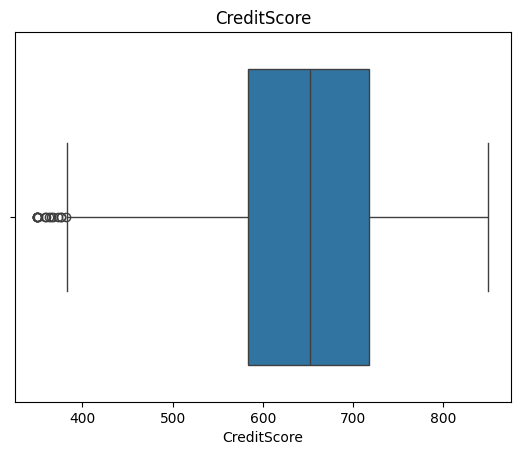

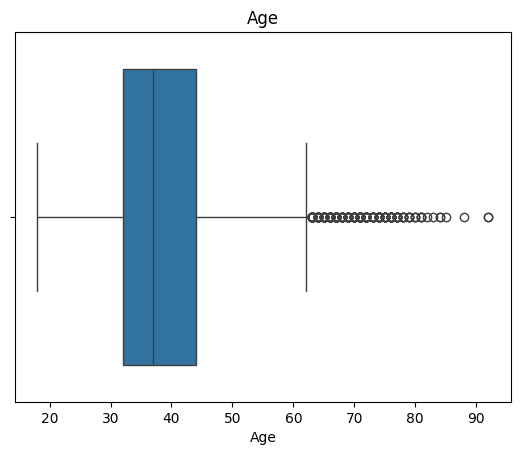

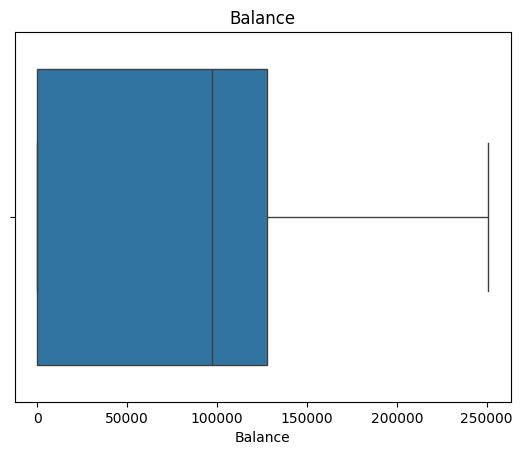

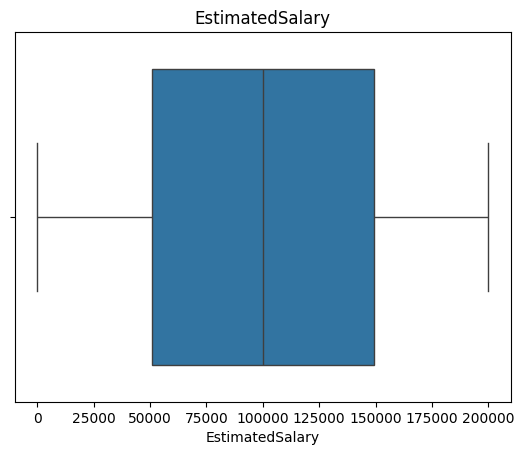

In [85]:
# outlier  check  :-
num= df.select_dtypes(include=['number']).columns.to_list()  #  here  we  only keept  those raws  we need to  check  or  treat  for  the  outlier 
                                                            # so  it is  classification  problem  then  we  not  include  outlier  in  target  columns which  is exited  so  we  remove  it during  outlier

num = [col for col in num if col not in ['Exited', 'NumOfProducts','HasCrCard','IsActiveMember','Tenure']]  # we do not include these columns in outlier checking
# because they are either:
# 1. Target variable (Exited)
# 2. Binary indicators (HasCrCard, IsActiveMember)
# 3. Discrete / bounded count features (NumOfProducts)
# 4. Bounded ordinal feature with valid domain values (Tenure: 0–10)



for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

    

percentaile_75 = df[num].quantile(0.75)
percentaile_25 = df[num].quantile(0.25)

IQR =  percentaile_75 - percentaile_25 

upper_limit = percentaile_75 + 1.5*IQR
lower_limit = percentaile_25 - 1.5*IQR

df[num] = df[num].clip(lower = lower_limit,upper = upper_limit,axis=1)




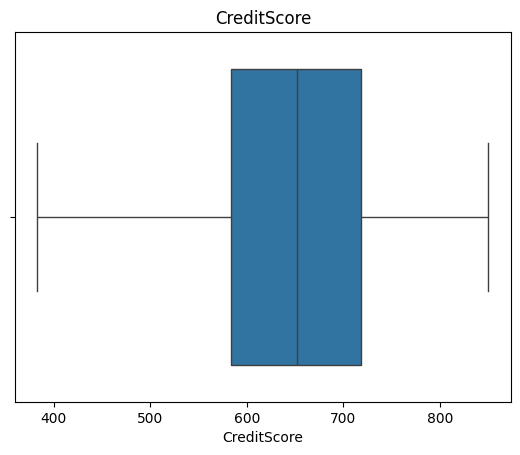

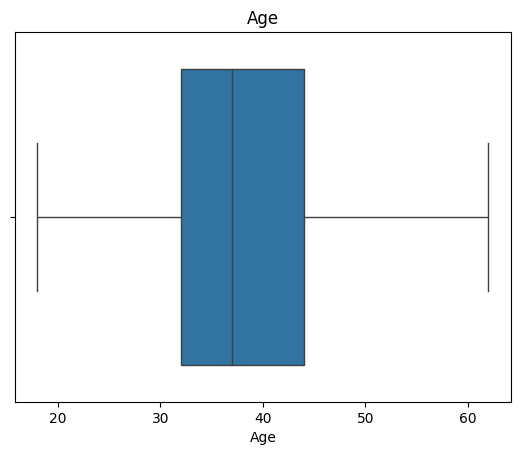

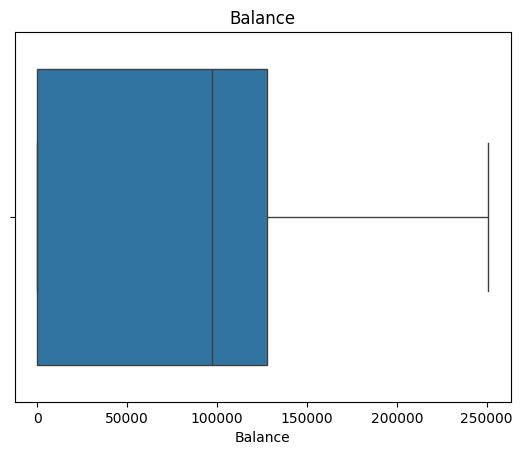

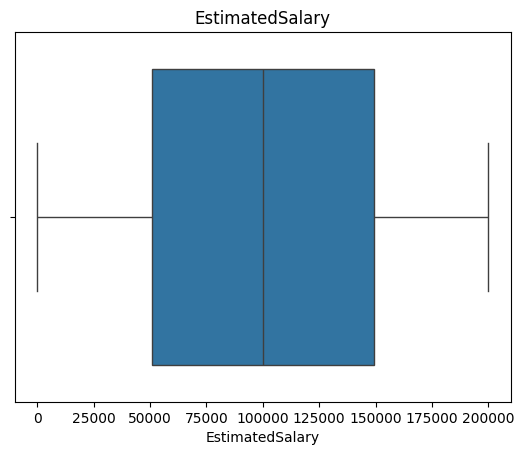

In [86]:
for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [87]:
df.isnull().sum() # see  no need  cca  

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [88]:
from  sklearn.compose import  ColumnTransformer 
from  sklearn.pipeline  import  Pipeline


from  sklearn.preprocessing  import  StandardScaler
from  sklearn.preprocessing  import  OneHotEncoder

In [89]:
from sklearn.model_selection import train_test_split 
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [90]:
x=df.drop(columns=['Exited'])
y=df['Exited']


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [91]:
numeric_col = x_train.select_dtypes(include=['number']).columns.tolist()
cate_col    = x_train.select_dtypes(include=['object','category']).columns.tolist()


Pipline_numer =  Pipeline([('standerd_scale',StandardScaler())])

Pipline_cateo =  Pipeline([('enco',OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', Pipline_numer, numeric_col),
    ('cat', Pipline_cateo, cate_col)
],remainder='drop')

In [92]:
from sklearn.linear_model import LogisticRegression

lr  =  Pipeline(steps=[
    ('preprocessor',preprocessor),     
    ('classifier',LogisticRegression(penalty='l2',
        solver='lbfgs',
        C=0.1,
        max_iter=1000))])

In [93]:
lr.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [94]:
from sklearn.metrics import accuracy_score

y_pred = lr.predict(x_test)

accuracy_score(y_test, y_pred)

0.8165

In [95]:
# i check  self
# Scores
train_score = lr.score(x_train, y_train)
test_score  = lr.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score :", test_score)

Train Score: 0.8195
Test Score : 0.8165


In [96]:
#   sir  task  implemnt  linear regression  on  insurance  dataset  

In [97]:
import  matplotlib.pyplot as  plt  
import seaborn as sns 
import  numpy as np 
import  pandas as pd 
df = pd.read_csv("C:\\Users\\Admin\\ml  models - p\\insurance - insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


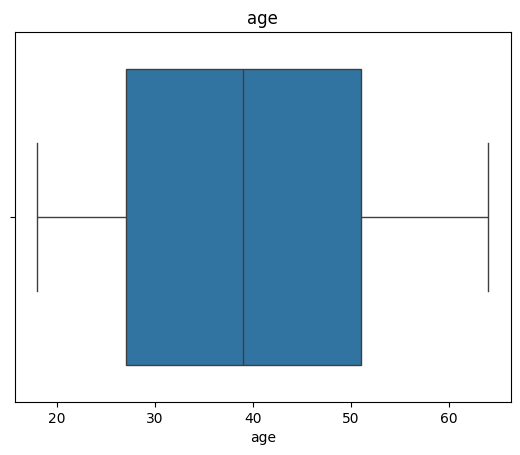

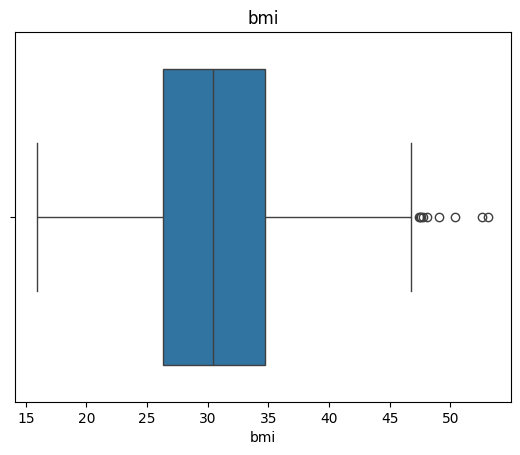

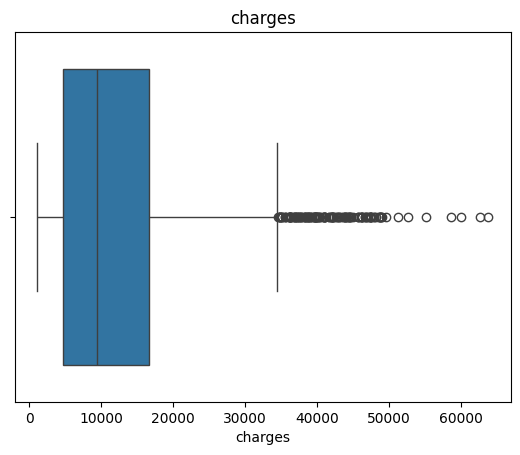

In [98]:
# outlier  check  :-
num= df.select_dtypes(include=['number']).columns.to_list()  

num = [col for col in num if col not in ['children']]  # df may  mojud  per  , outlier  may nhi mojud


for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

    

percentaile_75 = df[num].quantile(0.75)
percentaile_25 = df[num].quantile(0.25)

IQR =  percentaile_75 - percentaile_25 

upper_limit = percentaile_75 + 1.5*IQR
lower_limit = percentaile_25 - 1.5*IQR

df[num] = df[num].clip(lower = lower_limit,upper = upper_limit,axis=1)




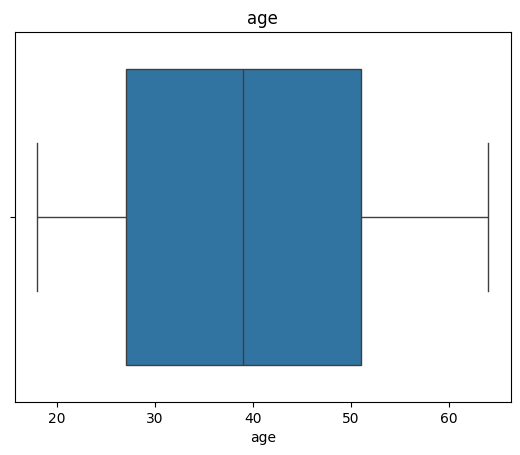

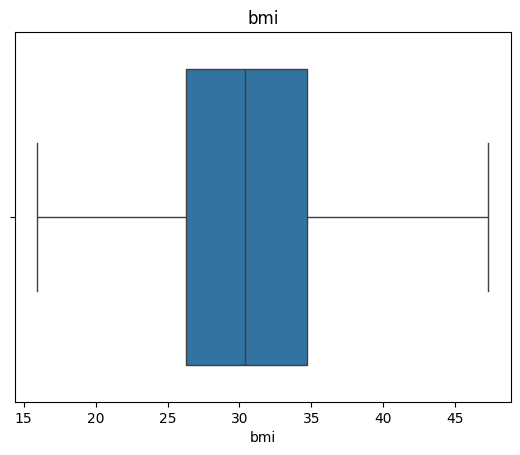

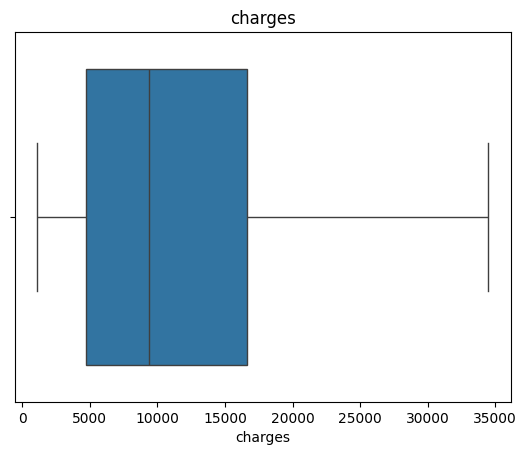

In [99]:
for  i  in num:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [100]:
df.isnull().sum() # see  no need  cca  


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [101]:
from  sklearn.compose import  ColumnTransformer 
from  sklearn.pipeline  import  Pipeline


from  sklearn.preprocessing  import  StandardScaler
from  sklearn.preprocessing  import  OneHotEncoder

In [102]:
from sklearn.model_selection import train_test_split 
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [103]:
x= df.drop(columns=['charges'])
y= df['charges']

In [104]:
from  sklearn.model_selection import  train_test_split
x_train , x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [105]:
numeric_col = x_train.select_dtypes(include=['number']).columns.tolist()
cate_col    = x_train.select_dtypes(include=['object','category']).columns.tolist()


Pipline_numer =  Pipeline([('standerd_scale',StandardScaler())])

Pipline_cateo =  Pipeline([('enco',OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', Pipline_numer, numeric_col),
    ('cat', Pipline_cateo, cate_col)
],remainder='drop')

In [106]:
from sklearn.linear_model import LinearRegression

lr  =  Pipeline(steps=[
    ('preprocessor',preprocessor),     
    ('leg',LinearRegression())])

In [107]:
lr.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('leg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
y_pred =  lr.predict(x_test)

In [109]:
from  sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7841002156994548

In [110]:
train_r2_lr = lr.score(x_train, y_train)
test_r2_lr  = lr.score(x_test, y_test)

print(train_r2_lr ,test_r2_lr)       


0.7376387881253277 0.7841002156994548
